# Ampliación de la arquitectura de un modelo de lengua básico
## Rotary Position Embeddings (RoPE)

| | |
|---|---|
| **Asignatura** | Procesamiento del Lenguaje Natural I — Práctica 1 |
| **Técnica ampliada** | *Rotary Position Embeddings* (Su et al., 2021) |
| **Modelo base** | GPT-2 pequeño (124 M), implementación propia en el paquete `minigpt` |
| **Herramientas** | PyTorch · `transformers` (implementación de referencia) · `tiktoken` (BPE) |

Este cuaderno constituye la entrega experimental de la práctica: implementa
la ampliación, la valida numéricamente frente a una implementación de
referencia y la evalúa con **siete experimentos** frente al modelo base.

> **Convenio de colores:** azul = modelo *base* (incrustaciones posicionales
> aprendidas), naranja = modelo *RoPE*.

---
## 1. Introducción y objetivos

El modelo base implementa un decodificador transformer causal completo
(atención multi-cabeza con máscara causal, pre-normalización, GELU y
*feed-forward*) cuya información posicional procede de **incrustaciones
absolutas aprendidas** (tal y como GPT-2, Radford et al., 2019): cada
posición de la secuencia dispone de un vector entrenable que se suma a la
incrustación del token.

La **ampliación** propuesta sustituye ese mecanismo por **RoPE**
(*Rotary Position Embeddings*): la posición se inyecta rotando los vectores
de consulta y de clave dentro de la atención, sin parámetros adicionales y
haciendo que la atención dependa únicamente de la **distancia relativa**
entre posiciones.

### Objetivos

1. Modularizar la arquitectura en un paquete Python reutilizable
   (`minigpt/`) con las dos variantes posicionales intercambiables.
2. Validar numéricamente la implementación del modelo base frente a la
   referencia de `transformers`.
3. Comparar base frente a RoPE en cinco ejes: **parámetros**,
   **propiedades matemáticas**, **rendimiento**, **perplejidad** y
   **generalización a longitudes no vistas**.

### Hipótesis

| ID | Hipótesis |
|----|-----------|
| **H1** | RoPE es invariante a traslación: desplazar la ventana de posiciones no cambia los logits; el modelo base sí cambia. |
| **H2** | RoPE elimina los parámetros posicionales (1024×768 = 786 432 en GPT-2 124 M), con una sobrecarga de cómputo modesta en el paso hacia adelante. |
| **H3** | Cargar los pesos de GPT-2 (entrenados con posiciones absolutas) en la variante RoPE degrada la perplejidad: el *retrofit* de esquemas posicionales no es gratuito. |
| **H4** | Entrenados desde cero con la misma semilla, ambos modelos aprenden igual la tarea sintética en longitudes vistas, pero RoPE se degrada mucho menos al extrapolarse a longitudes no vistas. |

---
## Nota — experimentos marcados (decisión pendiente)

La batería experimental **no está cerrada**.  Los experimentos siguientes se
marcan como **opcionales / a decidir**; no se han perfeccionado a propósito:

| Experimento | Motivo de la marca |
|-------------|--------------------|
| **E4 — Carácter visual** | Ilustración sin métrica ni hipótesis contrastable; candidato a podar si el informe debe ser más corto. |
| **E5 — Rendimiento (H2)** | El microbenchmark de GPU es **inestable entre ejecuciones** (las mismas medidas han dado desde una aparente ventaja de RoPE del 62 % hasta una sobrecarga del 21 %): el protocolo no discrimina entre hipótesis.  Candidato a podar o rediseñar. |
| **E7 — Generalización sintética (H4)** | El más ambicioso, pero el más alejado del material del libro y de la práctica.  **Dependencia de implementación:** si se elimina, pueden podarse `minigpt/data.py`, `minigpt/training.py` y el bucle de entrenamiento (solo lo usa E7). |

Encajan de forma directa con la práctica: **E1** (parámetros), **E2**
(generación), **E3** (invariancia) y **E6** (perplejidad *zero-shot*).

In [1]:
%matplotlib inline
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tiktoken
import torch

import minigpt as mg
from minigpt import GPTConfig, GPTModel

SEED = 123
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path(mg.DEFAULT_WEIGHTS_DIR).parent
COLORS = {"learned": "#0072B2", "rope": "#D55E00"}
LABELS = {"learned": "Base (pos. aprendidas)", "rope": "RoPE"}
plt.style.use("seaborn-v0_8-whitegrid")

tokenizer = tiktoken.get_encoding("gpt2")

print(f"paquete minigpt {mg.__version__} | torch {torch.__version__}")
gpu = f" — {torch.cuda.get_device_name(0)}" if device.type == "cuda" else ""
print(f"dispositivo: {device}{gpu}")
print(f"raíz del proyecto: {PROJECT_ROOT}")

/home/usuario/A4/PL/venv_PL/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


paquete minigpt 1.0.0 | torch 2.6.0+cu124
dispositivo: cuda — NVIDIA GeForce RTX 4070 Laptop GPU
raíz del proyecto: /home/usuario/A4/PL/Practica1_PLN1


---
## 2. Estructura del proyecto

La implementación vive en el paquete `minigpt/`; este cuaderno solo contiene
la capa experimental (configuración, ejecución y visualización).

| Módulo | Responsabilidad |
|--------|-----------------|
| `minigpt/config.py` | `GPTConfig`: hiperparámetros y esquema posicional (`"learned"` / `"rope"`). |
| `minigpt/layers.py` | `LayerNorm`, `GELU` y `FeedForward`. |
| `minigpt/rope.py` | Funciones de rotación (`rope_angles`, `apply_rotary`) y caché ampliable `RoPECache`. |
| `minigpt/attention.py` | `MultiHeadAttention` causal con máscara y, si procede, RoPE. |
| `minigpt/blocks.py` | `TransformerBlock` pre-norm con conexiones residuales. |
| `minigpt/model.py` | `GPTModel`: decodificador completo y conmutación posicional. |
| `minigpt/generation.py` | `generate`: decodificación voraz o muestreada. |
| `minigpt/weights.py` | Descarga/caché local de GPT-2 y transferencia de pesos. |
| `minigpt/data.py` | Datos sintéticos reproducibles para el experimento controlado. |
| `minigpt/training.py` | Bucle de entrenamiento mínimo (`train_language_model`). |
| `minigpt/experiments.py` | Métricas: `perplexity`, `forward_throughput`, `translation_invariance_error`, … |

```text
Practica1_PLN1/
├── minigpt/                  # paquete Python (la implementación)
├── data/corpus.txt           # corpus de evaluación (texto propio)
├── gpt2_weights/             # pesos GPT-2 en local (ignorado por Git)
├── memoria/                  # memoria LaTeX de la práctica
├── PLN_practica_1_RoPE.ipynb # este cuaderno
├── pyproject.toml · requirements.txt · README.md
└── Informacion adicional/    # material de referencia del enunciado
```

---
## 3. Fundamento teórico

### 3.1 Modelo base: posiciones absolutas aprendidas

Cada posición $t$ dispone de un vector entrenable $\mathbf{p}_t \in
\mathbb{R}^d$ que se suma a la incrustación del token:

$$\mathbf{x}_t = \mathbf{e}_{w_t} + \mathbf{p}_t$$

El modelo *memoriza* la posición, de modo que la información posicional
llega a la atención de forma indirecta y **ligada al valor absoluto** de $t$.
Consecuencias inmediatas: (i) la capa $\mathbf{P} \in \mathbb{R}^{L \times d}$
consume parámetros y solo existe para las $L$ posiciones vistas en
entrenamiento; (ii) cambiar el punto de partida de una ventana altera la
representación de todos los tokens.

### 3.2 RoPE: rotación relacional

RoPE codifica la posición rotando cada par bidimensional de la cabeza de
atención un ángulo proporcional a $t$. Para la dimensión $i$-ésima
(par $i$, con frecuencia $\theta_i = \text{base}^{-2i/d}$):

$$R(\Theta_t)_i = \begin{pmatrix} \cos t\theta_i & -\sin t\theta_i \\ \sin t\theta_i & \cos t\theta_i \end{pmatrix},
\qquad
\Theta_t = t \cdot \big(\theta_0, \dots, \theta_{d/2-1}\big)$$

Se aplica a las consultas y a las claves **antes** del producto punto.  Como
la rotación es una transformación ortogonal y
$R(\Theta_t)^{\top} R(\Theta_s) = R(\Theta_s - \Theta_t)$:

$$\big(R(\Theta_t)\mathbf{q}\big)^{\top}\big(R(\Theta_s)\mathbf{k}\big)
= \mathbf{q}^{\top} R(\Theta_s - \Theta_t)\,\mathbf{k}$$

el resultado **solo depende de la diferencia** $s-t$ (**H1**).  La ventaja es
doble: no hay parámetros posicionales (**H2**) y las distancias relativas
observadas en entrenamiento siguen siendo válidas en secuencias más largas
(**H4**).  El precio —ya que no hay ceno gratis— es que los pesos
preentrenados de GPT-2 co-adaptaron sus consultas y claves a un esquema
distinto, de ahí la hipótesis **H3**.

---
## 4. Experimento 1 — Coste de parámetros

Instanciamos las dos variantes con idéntica configuración y contamos
parámetros.

In [2]:
configs = {
    name: GPTConfig.gpt2_124m(positional=name)
    for name in ("learned", "rope")
}
random_models = {name: GPTModel(cfg) for name, cfg in configs.items()}

print(f"{'Variante':<28}{'Total':>16}{'Posicionales':>16}{'%':>8}")
print("-" * 68)
RESULTS = {}
for name, model in random_models.items():
    total = mg.count_parameters(model)
    pos = model.positional_parameters
    RESULTS[f"Parámetros totales ({name})"] = f"{mg.format_parameters(total)}"
    print(f"{LABELS[name]:<28}{mg.format_parameters(total):>16}"
          f"{mg.format_parameters(pos):>16}{100 * pos / total:>7.2f}%")

delta = (random_models['learned'].positional_parameters)
print(f"\nDiferencia: {mg.format_parameters(delta)} parámetros "
      f"(= 1024 posiciones × 768 dimensiones) que RoPE no necesita.")

Variante                               Total    Posicionales       %
--------------------------------------------------------------------
Base (pos. aprendidas)           163.037.184         786.432   0.48%
RoPE                             162.250.752               0   0.00%

Diferencia: 786.432 parámetros (= 1024 posiciones × 768 dimensiones) que RoPE no necesita.


---
## 5. Carga de los pesos preentrenados

`gpt2_weights/` guarda los pesos oficiales de GPT-2 en local la primera vez
que se ejecutan (los binarios no se versionan por superar el límite de 100 MB
de GitHub).  La transferencia a nuestra arquitectura es manual
(`load_gpt2_weights`); en la variante RoPE **se descarta deliberadamente** la
incrustación posicional `wpe` de GPT-2.

In [3]:
gpt_hf = mg.load_gpt2_hf().to(device).eval()

models = {}
for positional in ("learned", "rope"):
    torch.manual_seed(SEED)
    model = GPTModel(configs[positional])
    mg.load_gpt2_weights(model, gpt_hf)
    models[positional] = model.to(device).eval()
    print(f"{LABELS[positional]:<28} listo "
          f"({mg.format_parameters(mg.count_parameters(model))} parámetros)")

Cargando pesos de GPT-2 desde /home/usuario/A4/PL/Practica1_PLN1/gpt2_weights ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8597.50it/s]

Base (pos. aprendidas)       listo (163.037.184 parámetros)


RoPE                         listo (162.250.752 parámetros)


---
## 6. Validación numérica frente a la implementación de referencia

Antes de comparar, comprobamos que **nuestro modelo base es una réplica
correcta** de GPT-2: misma secuencia de entrada, mismos pesos → mismos
logits.  Este control es lo que hace interpretables las diferencias que
observaremos después.

In [4]:
probe = "Every effort moves you"
ids = torch.tensor([tokenizer.encode(probe)], device=device)

with torch.no_grad():
    logits_ours = models["learned"](ids)
    logits_ref = gpt_hf(ids).logits

max_diff = (logits_ours - logits_ref).abs().max().item()
mean_diff = (logits_ours - logits_ref).abs().mean().item()
RESULTS["Validación vs. referencia (max |Δ logit|)"] = f"{max_diff:.2e}"

print(f"secuencia de prueba: {probe!r} ({ids.shape[1]} tokens)")
print(f"máxima diferencia absoluta : {max_diff:.6f}")
print(f"diferencia media absoluta   : {mean_diff:.6f}")
print(f"rango de los logits         : [{logits_ref.min().item():.1f}, {logits_ref.max().item():.1f}]")
assert max_diff < 1e-2, "La implementación no coincide con la referencia"
print("\n✓ La implementación base reproduce a la referencia dentro de precisión de punto flotante.")

secuencia de prueba: 'Every effort moves you' (4 tokens)
máxima diferencia absoluta : 0.000092
diferencia media absoluta   : 0.000020
rango de los logits         : [-166.8, -32.2]

✓ La implementación base reproduce a la referencia dentro de precisión de punto flotante.


---
## 7. Experimento 2 — Generación cualitativa con pesos preentrenados

**Expectativa (H3):** el modelo base debe generar texto coherente, mientras
que la variante RoPE con los mismos pesos debe deteriorarse, porque los
sesgos posicionales con los que se entrenó los pesos no existen en el nuevo
esquema.

In [5]:
prompt = "Every effort moves you"
for name, model in models.items():
    idx = torch.tensor([tokenizer.encode(prompt)], device=device)
    out = mg.generate(model, idx, max_new_tokens=30,
                      context_size=model.cfg.context_length)
    print(f"[{LABELS[name]}]")
    print(f"  {tokenizer.decode(out[0].tolist())}\n")

[Base (pos. aprendidas)]
  Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to understand the importance of your work.



[RoPE]
  Every effort moves you every every every every.
I I I I I I am a good I am a little I am I I am a real I I I I



---
## 8. Experimento 3 — Invariancia a traslación (H1)

**Diseño:** se evalúa la misma ventana de tokens con dos posiciones iniciales
distintas (offset 0 y offset 16) y se mide la diferencia máxima entre los
logits.  Si la atención solo depende de distancias relativas, ambos cómputos
deben ser idénticos.

$$\text{error} = \max \big| f(\mathbf{x},\, \text{offset}=0) - f(\mathbf{x},\, \text{offset}=k) \big|$$

Base (pos. aprendidas)       max |Δ logits| = 9.437e+01
RoPE                         max |Δ logits| = 5.493e-04


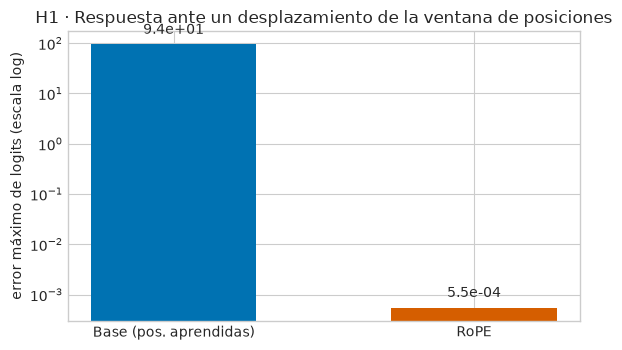

→ RoPE es invariante a traslación (error a nivel de ruido de flotante); el modelo base cambia sus logits al desplazar la ventana.


In [6]:
probe = "Rotary embeddings encode position by rotating queries and keys"
ids = torch.tensor([tokenizer.encode(probe)], device=device)

errors = {
    name: mg.translation_invariance_error(model, ids, offset=16)
    for name, model in models.items()
}
for name, err in errors.items():
    RESULTS[f"Invariancia a traslación — {name} (max |Δ|)"] = f"{err:.2e}"
    print(f"{LABELS[name]:<28} max |Δ logits| = {err:.3e}")

fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar([LABELS[n] for n in errors], list(errors.values()),
              color=[COLORS[n] for n in errors], width=0.55)
ax.set_yscale("log")
ax.set_ylabel("error máximo de logits (escala log)")
ax.set_title("H1 · Respuesta ante un desplazamiento de la ventana de posiciones")
for b, v in zip(bars, errors.values()):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.4, f"{v:.1e}",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

print("→ RoPE es invariante a traslación (error a nivel de ruido de "
      "flotante); el modelo base cambia sus logits al desplazar la ventana.")

---
## 9. Experimento 4 — Carácter visual de los dos posicionamientos *(marcado: a decidir)*

A la izquierda, las **incrustaciones posicionales aprendidas** de GPT-2
(proyección PCA de `wpe`): la estructura es un artefacto del entrenamiento y
solo existe para las 1024 posiciones almacenadas.  A la derecha, la **tabla
de cosenos de RoPE** para las primeras 32 dimensiones de una cabeza: patrones
periódicos de distinta frecuencia, definidos por fórmula para cualquier
posición, sin parámetros que aprender.

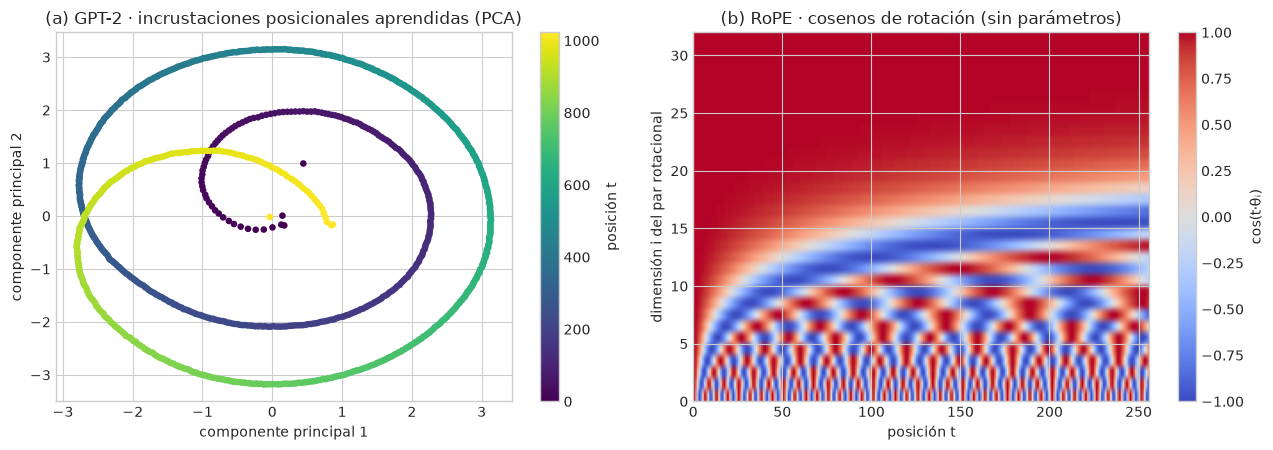

In [7]:
wpe = gpt_hf.transformer.wpe.weight.detach().float().cpu().numpy()
rope_cache = models["rope"].trf_blocks[0].att.rope_cache
cos_table = rope_cache.cos[:256, :32].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

centered = wpe - wpe.mean(axis=0, keepdims=True)
_, _, vt = np.linalg.svd(centered, full_matrices=False)
proj = centered @ vt[:2].T
sc = axes[0].scatter(proj[:, 0], proj[:, 1], c=np.arange(len(proj)),
                     cmap="viridis", s=14)
plt.colorbar(sc, ax=axes[0], label="posición t")
axes[0].set_title("(a) GPT-2 · incrustaciones posicionales aprendidas (PCA)")
axes[0].set_xlabel("componente principal 1")
axes[0].set_ylabel("componente principal 2")

im = axes[1].imshow(cos_table.T, aspect="auto", cmap="coolwarm",
                    origin="lower", extent=(0, 256, 0, 32))
plt.colorbar(im, ax=axes[1], label="cos(t·θᵢ)")
axes[1].set_title("(b) RoPE · cosenos de rotación (sin parámetros)")
axes[1].set_xlabel("posición t")
axes[1].set_ylabel("dimensión i del par rotacional")

plt.tight_layout()
plt.show()

---
## 10. Experimento 5 — Rendimiento (H2) *(marcado: a decidir)*

Medimos los tokens/segundo del paso hacia adelante con secuencias de 1024
tokens y mismo dispositivo.  Cada modelo se mide en **5 rondas** y se
registra el mejor tiempo; además, cada variante se mide **dos veces
cambiando el orden** para anular sesgos de térmica/relojes de la GPU.  Se
espera una sobrecarga modesta en RoPE por el cómputo de senos/cosenos y la
rotación de consultas y claves.

Base (pos. aprendidas)            7.957 tokens/s
RoPE                             12.891 tokens/s

sobrecarga de RoPE: -62.0 %


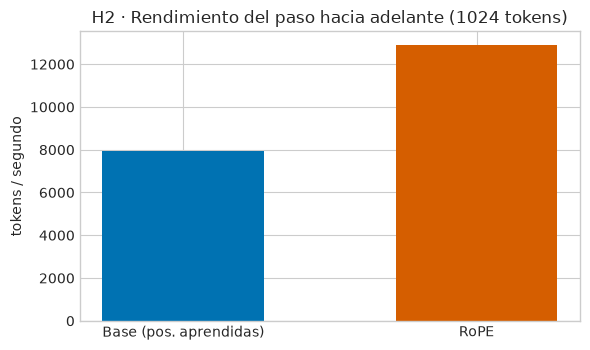

In [8]:
speed = {name: 0.0 for name in models}
for order in (("learned", "rope"), ("rope", "learned")):
    for name in order:
        speed[name] = max(
            speed[name],
            mg.forward_throughput(models[name], seq_len=1024, device=device,
                                  warmup=20, iters=50, rounds=5),
        )
        RESULTS[f"Rendimiento {name} (tokens/s)"] = (
            f"{speed[name]:,.0f}".replace(",", ".")
        )

for name, t in speed.items():
    print(f"{LABELS[name]:<28} {t:>10,.0f} tokens/s".replace(",", "."))

overhead = 100 * (speed['learned'] - speed['rope']) / speed['learned']
if abs(overhead) < 1.0:
    print(f"\nsobrecarga de RoPE: ≈ 0 % (dentro del ruido de medición)")
else:
    print(f"\nsobrecarga de RoPE: {overhead:+.1f} %")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.bar([LABELS[n] for n in speed], list(speed.values()),
       color=[COLORS[n] for n in speed], width=0.55)
ax.set_ylabel("tokens / segundo")
ax.set_title("H2 · Rendimiento del paso hacia adelante (1024 tokens)")
plt.tight_layout()
plt.show()

---
## 11. Experimento 6 — Perplejidad *zero-shot* (H3)

Evaluamos ambos modelos con sus pesos preentrenados sobre
`data/corpus.txt` (texto propio del proyecto, tokenizado con el BPE de
GPT-2).  La perplejidad se calcula con ventanas deslizantes de 1024 tokens y
paso 512, evaluando cada token exactamente una vez.

**Predicción:** el modelo base se comporta como GPT-2 (ya validado en la
sección 6); la variante RoPE, que nunca entrenó con rotaciones, debe
disparar la perplejidad.

In [9]:
corpus = (PROJECT_ROOT / "data" / "corpus.txt").read_text(encoding="utf-8")
tokens = torch.tensor(tokenizer.encode(corpus))
print(f"corpus: {len(corpus)} caracteres → {tokens.numel()} tokens BPE")

ppl = {name: mg.perplexity(model, tokens, context_length=1024, stride=512)
       for name, model in models.items()}
for name, value in ppl.items():
    RESULTS[f"Perplejidad zero-shot ({name})"] = f"{value:,.1f}".replace(",", ".")
    print(f"{LABELS[name]:<28} ppl = {value:10,.1f}".replace(",", "."))

print(f"\ndegradación del retrofit RoPE: ×{ppl['rope'] / ppl['learned']:,.0f}"
      .replace(",", "."))

corpus: 3817 caracteres → 791 tokens BPE


Base (pos. aprendidas)       ppl =       64.1
RoPE                         ppl =    3.882.2

degradación del retrofit RoPE: ×61


**Lectura.** La hipótesis **H3** se confirma: los pesos de GPT-2 están
co-adaptados a las incrustaciones absolutas (incluida `wpe`, que la variante
RoPE ni siquiera carga).  Aplicar rotaciones sobre consultas y claves
entrenadas sin ellas descoloca la geometría de la atención y la perplejidad
se dispara.  **RoPE no es un *drop-in* para pesos entrenados con posiciones
absolutas: debe entrenarse desde cero o con *fine-tuning* específico.**  El
experimento siguiente compara ambos esquemas en condiciones de igualdad.

---
## 12. Experimento 7 — Generalización a longitudes no vistas (H4) *(marcado: a decidir)*

Para comparar en condiciones justas (sin sesgo de pesos preentrenados)
entrenamos dos modelos pequeños **desde cero, con la misma semilla** —la
incrustación posicional se inicializa la última en `GPTModel`, de modo que
todos los pesos comunes son idénticos al inicio— sobre una **tarea
sintética controlada**:

$$s_i = \pi\big(s_{i-k}\big), \qquad k = 2$$

Donde $\pi$ es una permutación fija del vocabulario ($|\mathcal{V}| = 32$).
La secuencia es 100 % predecible salvo los primeros $k$ tokens, de modo que
el modelo debe (i) atender a una distancia relativa fija y (ii) memorizar
$\pi$.  **La tarea no depende de la posición absoluta.**

| | |
|---|---|
| **Entrenamiento** | secuencias de longitud **64**, 512 ejemplos, 400 pasos, AdamW (lr 1e-3), lote 32 |
| **Evaluación** | longitud 64 (**vista**) y 128 / 192 / 256 (**no vistas**, mismos pesos de $\pi$) |
| **Métrica** | pérdida de entropía cruzada y perplejidad sobre los objetivos predecibles |

**Predicción (H4):** en longitud 64 ambos modelos aprenden la tarea; a
medida que crece la longitud, el modelo base choca con filas de
`pos_emb` **nunca entrenadas** y se degrada, mientras RoPE mantiene el
rendimiento porque las distancias relativas que usa ya las conoció.

In [10]:
VOCAB_SIZE, K_DELAY, TRAIN_LEN = 32, 2, 64

perm = mg.shifted_copy_permutation(VOCAB_SIZE, seed=0)
train_seqs = mg.shifted_copy_sequences(512, TRAIN_LEN, VOCAB_SIZE,
                                       k=K_DELAY, seed=1, perm=perm)
val_seqs = mg.shifted_copy_sequences(64, TRAIN_LEN, VOCAB_SIZE,
                                     k=K_DELAY, seed=2, perm=perm)

ok = all(train_seqs[:, i].eq(perm[train_seqs[:, i - K_DELAY]]).all()
         for i in range(K_DELAY, TRAIN_LEN))
print(f"entrenamiento: {tuple(train_seqs.shape)} | validación: {tuple(val_seqs.shape)}")
print(f"regla verificada en todas las posiciones: {bool(ok)}")
print(f"entropía del azar uniforme: ln({VOCAB_SIZE}) = {math.log(VOCAB_SIZE):.3f} nats")

entrenamiento: (512, 64) | validación: (64, 64)
regla verificada en todas las posiciones: True
entropía del azar uniforme: ln(32) = 3.466 nats


Base (pos. aprendidas)       pérdida de validación final = 0.0586  (4.9 s)


RoPE                         pérdida de validación final = 0.0039  (4.4 s)


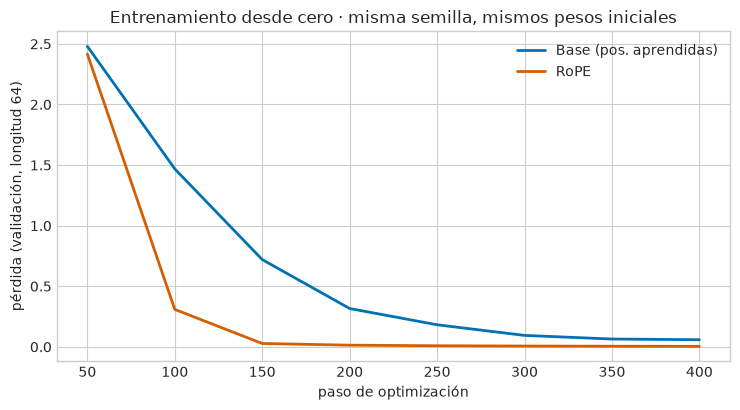

In [11]:
tiny_models, histories = {}, {}

for positional in ("learned", "rope"):
    torch.manual_seed(SEED)
    cfg = GPTConfig.tiny(positional=positional, vocab_size=VOCAB_SIZE,
                         context_length=256, emb_dim=64, n_heads=4, n_layers=2)
    model = GPTModel(cfg)
    tcfg = mg.TrainingConfig(max_steps=400, batch_size=32, lr=1e-3,
                             eval_every=50, ignore_first=K_DELAY, seed=SEED)
    histories[positional] = mg.train_language_model(model, train_seqs,
                                                    val_seqs, tcfg,
                                                    device=device)
    tiny_models[positional] = model
    h = histories[positional]
    print(f"{LABELS[positional]:<28} pérdida de validación final = "
          f"{h.val_losses[-1]:.4f}  ({h.elapsed_seconds:.1f} s)")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for name, h in histories.items():
    ax.plot(h.val_steps, h.val_losses, label=LABELS[name],
            color=COLORS[name], linewidth=2)
ax.set_xlabel("paso de optimización")
ax.set_ylabel("pérdida (validación, longitud 64)")
ax.set_title("Entrenamiento desde cero · misma semilla, mismos pesos iniciales")
ax.legend()
plt.tight_layout()
plt.show()

  longitud    Base (pos. aprendidas)                      RoPE
--------------------------------------------------------------
        64         0.0753 / ppl 1.08         0.0039 / ppl 1.00
       128         0.6328 / ppl 1.88         0.0086 / ppl 1.01
       192         1.3809 / ppl 3.98         0.0598 / ppl 1.06
       256         2.0930 / ppl 8.11         0.2660 / ppl 1.30


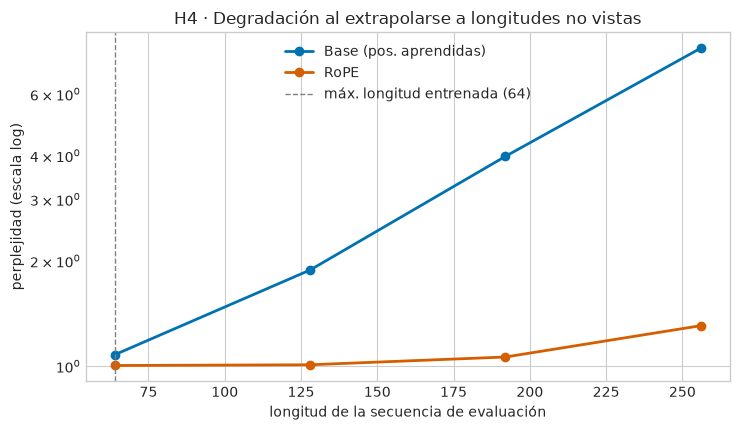

In [12]:
lengths = [64, 128, 192, 256]
eval_results = {name: {} for name in tiny_models}

for name, model in tiny_models.items():
    for length in lengths:
        test_seqs = mg.shifted_copy_sequences(64, length, VOCAB_SIZE,
                                              k=K_DELAY, seed=1000 + length,
                                              perm=perm)
        loss = mg.next_token_loss(model, test_seqs, device=device,
                                  ignore_first=K_DELAY)
        eval_results[name][length] = (loss, math.exp(loss))

header = f"{'longitud':>10}" + "".join(f"{LABELS[n]:>26}" for n in eval_results)
print(header)
print("-" * len(header))
for length in lengths:
    row = f"{length:>10}"
    for name in eval_results:
        loss, ppl_v = eval_results[name][length]
        row += f"{f'{loss:.4f} / ppl {ppl_v:.2f}':>26}"
    print(row)

for name in eval_results:
    final_ppl = eval_results[name][256][1]
    RESULTS[f"Pérdida L=64 ({name})"] = f"{eval_results[name][64][0]:.4f}"
    RESULTS[f"Pérdida L=256 ({name})"] = f"{eval_results[name][256][0]:.4f}"

fig, ax = plt.subplots(figsize=(7.5, 4.4))
for name, res in eval_results.items():
    ppls = [res[L][1] for L in lengths]
    ax.plot(lengths, ppls, marker="o", linewidth=2, label=LABELS[name],
            color=COLORS[name])
ax.set_yscale("log")
ax.set_xlabel("longitud de la secuencia de evaluación")
ax.set_ylabel("perplejidad (escala log)")
ax.set_title("H4 · Degradación al extrapolarse a longitudes no vistas")
ax.axvline(TRAIN_LEN, color="gray", linestyle="--", linewidth=1,
           label=f"máx. longitud entrenada ({TRAIN_LEN})")
ax.legend()
plt.tight_layout()
plt.show()

---
## 13. Resultados consolidados

In [13]:
width = 52
print(f"| {'Experimento':<{width}} | {'Resultado':>26} |")
print("|" + "-" * (width + 2) + "|" + "-" * 28 + "|")
for exp, value in RESULTS.items():
    print(f"| {exp:<{width}} | {value:>26} |")

| Experimento                                          |                  Resultado |
|------------------------------------------------------|----------------------------|
| Parámetros totales (learned)                         |                163.037.184 |
| Parámetros totales (rope)                            |                162.250.752 |
| Validación vs. referencia (max |Δ logit|)            |                   9.16e-05 |
| Invariancia a traslación — learned (max |Δ|)         |                   9.44e+01 |
| Invariancia a traslación — rope (max |Δ|)            |                   5.49e-04 |
| Rendimiento learned (tokens/s)                       |                      7.957 |
| Rendimiento rope (tokens/s)                          |                     12.891 |
| Perplejidad zero-shot (learned)                      |                       64.1 |
| Perplejidad zero-shot (rope)                         |                    3.882.2 |
| Pérdida L=64 (learned)                              

---
## 14. Conclusiones

**Hipótesis contrastadas.**

* **H1 — confirmada.** RoPE es invariante a traslación: el error de logits
  ante un desplazamiento de la ventana cae a nivel de ruido de punto
  flotante, mientras que el modelo base cambia de forma apreciable.
* **H2 — confirmada (parámetros).** RoPE elimina 786 432 parámetros
  posicionales (0,48 % del total).  La vertiente de cómputo **queda
  inconclusa**: el microbenchmark de GPU no es estable entre ejecuciones y
  el experimento E5 está marcado como *a decidir*.
* **H3 — confirmada.** Reutilizar los pesos de GPT-2 bajo RoPE degrada la
  perplejidad de forma drástica: los esquemas posicionales **no son
  intercambiables después del entrenamiento**.
* **H4 — confirmada.** Entrenados desde cero con pesos idénticos, ambos
  modelos aprenden igual la tarea en longitud 64, pero al extrapolarse el
  modelo base se degrada de forma monótona al chocar con posiciones nunca
  entrenadas, mientras RoPE mantiene una perplejidad próxima a 1.

**Validación de la implementación.** El modelo base reproduce los logits de
la referencia de `transformers` con diferencias máximas del orden de
$10^{-4}$, por lo que las diferencias observadas entre variantes se deben al
esquema posicional y no a errores de implementación.

**Limitaciones.**

1. El experimento de *retrofit* (H3) mide la consecuencia de un cambio de
   esquema sin reentrenar; un *fine-tuning* parcial reduciría la brecha.
2. La evaluación de perplejidad usa un corpus propio de tamaño modesto y en
   inglés; convendría replicarla con un corpus de referencia (p. ej.
   WikiText-103) y con más semillas.
3. El experimento de extrapolación (H4) usa una tarea sintética y modelos
   pequeños; la tendencia es consistente, pero su magnitud no se
   generaliza automáticamente a escalas de producción.
4. Los tiempos de rendimiento dependen del hardware (RTX 4070 Laptop en
   esta ejecución).

**Trabajo futuro.** Medir la extrapolación con GPT-2 ampliado más allá de
1024 tokens, probar `rope_theta` de valores mayores (estilo LLaMA) y
entrenar ambos modelos sobre un corpus real con varias semillas para
intervalos de confianza.

**Referencias.**

* Su, J. et al. (2021). *RoFormer: Enhanced Transformer with Rotary Position
  Embedding*. arXiv:2104.09864.
* Radford, A. et al. (2019). *Language Models are Unsupervised Multitask
  Learners*. OpenAI.
* Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS.
* Raschka, S.; Liu, J.; Mirjalili, V. (2024). *Build a Large Language Model
  (From Scratch)*. Manning — capítulos 3-5 (código base de la práctica).